# MRI Fractionwise KL Divergence Plotting

This notebook loads the aggregated MRI results and plots fractionwise KL divergence values.

In [44]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from pathlib import Path

# Use default matplotlib color cycle (blue/orange)
matplotlib.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=['#1f77b4', '#ff7f0e'])

# Figure dimensions - publication ready
fig_width = 3.0   # inches per plot (wider for fractionwise data)
fig_height = 2.4  # inches per plot

# Font sizes
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

## Load MRI Results Data

In [40]:
# Load the aggregated results JSON file
results_path = Path("./results/json/aggregated_results_mri.json")

# Check if file exists
if not results_path.exists():
    print(f"❌ Results file not found at: {results_path}")
    print("Please run the MRI benchmark first to generate results.")
    print("Command: python mri_kl_benchmark.py --methods baseline")
else:
    print(f"✅ Loading results from: {results_path}")
    
    with open(results_path, 'r') as f:
        results = json.load(f)
    
    print(f"Available methods: {list(results.keys())}")

✅ Loading results from: results/json/aggregated_results_mri.json
Available methods: ['mcal_ce', 'mcal_ce_uncond']


In [45]:
# Check if both mcal_ce and mcal_ce_uncond methods exist in results
methods_to_compare = ['mcal_ce', 'mcal_ce_uncond']
missing_methods = [method for method in methods_to_compare if method not in results]

if missing_methods:
    print(f"❌ Missing methods: {missing_methods}")
    print(f"Available methods: {list(results.keys())}")
    print("Please run the MRI benchmark with both mcal_ce and mcal_ce_uncond methods first.")
    print("Command: python mri_kl_benchmark.py --methods mcal_ce mcal_ce_uncond")
else:
    print("✅ Both mcal_ce and mcal_ce_uncond methods found!")
    
    # Extract fractionwise data for both methods
    methods_data = {}
    
    for method in methods_to_compare:
        method_results = results[method]
        
        if 'fraction_wise_results_transformed' in method_results:
            fraction_data = method_results['fraction_wise_results_transformed']
            
            methods_data[method] = {
                'mean_argmax': np.array(fraction_data['mean_argmax']),
                'std_argmax': np.array(fraction_data['std_argmax'])
            }
            
            print(f"✅ {method} fractionwise data loaded successfully")
        else:
            print(f"❌ Fractionwise results not found for {method}")
            print(f"Available keys: {list(method_results.keys())}")
    
    # Create fraction labels if we have data
    if methods_data:
        # Use the first method to determine number of fractions
        first_method = list(methods_data.keys())[0]
        n_fractions = len(methods_data[first_method]['mean_argmax'])
        fractions = np.arange(n_fractions) / 16
        fraction_labels = [f"{i}/16" for i in range(n_fractions)]
        
        print(f"Number of fractions: {n_fractions}")
        print(f"Fraction range: 0/16 to {n_fractions-1}/16")
        
        # Print summary for both methods
        for method in methods_to_compare:
            if method in methods_data:
                data = methods_data[method]
                print(f"\n{method.upper()} SUMMARY:")
                print(f"   Mean KL (argmax) range: {data['mean_argmax'].min():.6f} to {data['mean_argmax'].max():.6f}")

✅ Both mcal_ce and mcal_ce_uncond methods found!
✅ mcal_ce fractionwise data loaded successfully
✅ mcal_ce_uncond fractionwise data loaded successfully
Number of fractions: 16
Fraction range: 0/16 to 15/16

MCAL_CE SUMMARY:
   Mean KL (argmax) range: 0.000005 to 0.072191

MCAL_CE_UNCOND SUMMARY:
   Mean KL (argmax) range: 0.000016 to 0.565370


In [46]:
# Check if baseline method exists in results
if 'baseline' not in results:
    print("❌ Baseline method not found in results")
    print(f"Available methods: {list(results.keys())}")
else:
    baseline_results = results['baseline']
    
    # Extract fractionwise data
    if 'fraction_wise_results' in baseline_results:
        fraction_data = baseline_results['fraction_wise_results']
        
        # Get the data arrays
        mean_argmax = np.array(fraction_data['mean_argmax'])
        std_argmax = np.array(fraction_data['std_argmax'])
        mean_prob = np.array(fraction_data['mean_prob'])
        std_prob = np.array(fraction_data['std_prob'])
        
        # Create fraction labels (0/16, 1/16, ..., 15/16)
        n_fractions = len(mean_argmax)
        fractions = np.arange(n_fractions) / 16
        fraction_labels = [f"{i}/16" for i in range(n_fractions)]
        
        print(f"✅ Baseline fractionwise data loaded successfully")
        print(f"Number of fractions: {n_fractions}")
        print(f"Fraction range: 0/16 to {n_fractions-1}/16")
        print(f"Mean KL (argmax) range: {mean_argmax.min():.6f} to {mean_argmax.max():.6f}")
        print(f"Mean KL (prob) range: {mean_prob.min():.6f} to {mean_prob.max():.6f}")
    else:
        print("❌ Fractionwise results not found for baseline method")
        print(f"Available keys: {list(baseline_results.keys())}")

❌ Baseline method not found in results
Available methods: ['mcal_ce', 'mcal_ce_uncond']


## Plot MCal_CE vs MCal_CE_Uncond Fractionwise KL Divergence (Argmax Only)

Saving plots to: /home/antonxue/shailesh/MCal/experiments/vision/figures


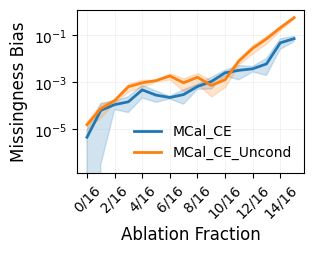

Saved: /home/antonxue/shailesh/MCal/experiments/vision/figures/mri_mcal_comparison_fractionwise_kl_argmax_log.pdf

✅ MRI MCal comparison log plot saved to /home/antonxue/shailesh/MCal/experiments/vision/figures/


In [47]:
# Create comparison plot for MCal_CE vs MCal_CE_Uncond with log scale (Argmax only)
if 'methods_data' in locals() and len(methods_data) >= 2:
    # Ensure output directory exists
    output_dir = 'figures'
    os.makedirs(output_dir, exist_ok=True)
    abs_output_dir = Path(output_dir).absolute()
    print(f"Saving plots to: {abs_output_dir}")
    
    # Get data for both methods
    mcal_ce_data = methods_data['mcal_ce']
    mcal_ce_uncond_data = methods_data['mcal_ce_uncond']
    
    # Plot: KL Divergence (Argmax/One-hot) Comparison - LOG SCALE
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
    
    # MCal_CE line and confidence band
    ax.plot(fractions, mcal_ce_data['mean_argmax'], '-', 
            label='MCal_CE', linewidth=2, color='#1f77b4')
    ax.fill_between(fractions, 
                    mcal_ce_data['mean_argmax'] - mcal_ce_data['std_argmax'], 
                    mcal_ce_data['mean_argmax'] + mcal_ce_data['std_argmax'],
                    alpha=0.2, color='#1f77b4')
    
    # MCal_CE_Uncond line and confidence band
    ax.plot(fractions, mcal_ce_uncond_data['mean_argmax'], '-', 
            label='MCal_CE_Uncond', linewidth=2, color='#ff7f0e')
    ax.fill_between(fractions, 
                    mcal_ce_uncond_data['mean_argmax'] - mcal_ce_uncond_data['std_argmax'], 
                    mcal_ce_uncond_data['mean_argmax'] + mcal_ce_uncond_data['std_argmax'],
                    alpha=0.2, color='#ff7f0e')
    
    ax.set_xlabel('Ablation Fraction')
    ax.set_ylabel('Missingness Bias')
    ax.set_yscale('log')  # LOG SCALE
    ax.legend(loc='best', frameon=False)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.tick_params(axis='both', which='major')
    
    # Set x-axis ticks
    tick_positions = np.arange(0, len(fractions), 2)
    ax.set_xticks(fractions[tick_positions])
    ax.set_xticklabels([fraction_labels[i] for i in tick_positions], rotation=45)
    
    plt.tight_layout(pad=0.2)
    plt.savefig(f'{output_dir}/mri_mcal_comparison_fractionwise_kl_argmax_log.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {abs_output_dir}/mri_mcal_comparison_fractionwise_kl_argmax_log.pdf")
    
    print(f"\n✅ MRI MCal comparison log plot saved to {abs_output_dir}/")
    
else:
    print("❌ No comparison data available to plot")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

## MCal_CE vs MCal_CE_Uncond Comparison Statistics

In [32]:
# Detailed comparison statistics between MCal_CE and MCal_CE_Uncond
if 'methods_data' in locals() and len(methods_data) >= 2:
    print("📊 MRI: MCAL_CE vs MCAL_CE_UNCOND FRACTIONWISE KL DIVERGENCE COMPARISON")
    print("=" * 80)
    
    mcal_ce_data = methods_data['mcal_ce']
    mcal_ce_uncond_data = methods_data['mcal_ce_uncond']
    
    # Argmax KL Divergence Comparison
    print(f"\n🎯 ARGMAX/ONE-HOT KL DIVERGENCE COMPARISON:")
    print(f"{'Method':<20} {'Min':<12} {'Max':<12} {'Mean':<12} {'Std':<12}")
    print("-" * 70)
    print(f"{'MCal_CE':<20} {mcal_ce_data['mean_argmax'].min():<12.6f} {mcal_ce_data['mean_argmax'].max():<12.6f} "
          f"{mcal_ce_data['mean_argmax'].mean():<12.6f} {mcal_ce_data['mean_argmax'].std():<12.6f}")
    print(f"{'MCal_CE_Uncond':<20} {mcal_ce_uncond_data['mean_argmax'].min():<12.6f} {mcal_ce_uncond_data['mean_argmax'].max():<12.6f} "
          f"{mcal_ce_uncond_data['mean_argmax'].mean():<12.6f} {mcal_ce_uncond_data['mean_argmax'].std():<12.6f}")
    
    # Calculate improvement
    argmax_improvement = ((mcal_ce_data['mean_argmax'].mean() - mcal_ce_uncond_data['mean_argmax'].mean()) 
                         / mcal_ce_data['mean_argmax'].mean()) * 100
    print(f"\n   → MCal_CE_Uncond vs MCal_CE improvement: {argmax_improvement:+.2f}%")
    
    # Fraction-wise comparison - show largest differences
    print(f"\n📈 FRACTION-WISE ANALYSIS:")
    argmax_diff = mcal_ce_data['mean_argmax'] - mcal_ce_uncond_data['mean_argmax']
    
    # Find fractions with largest improvements for MCal_CE_Uncond
    best_argmax_fraction = np.argmax(argmax_diff)  # Largest positive difference (MCal_CE higher)
    
    print(f"   Largest MCal_CE_Uncond advantage (Argmax): Fraction {best_argmax_fraction}/16")
    print(f"      MCal_CE: {mcal_ce_data['mean_argmax'][best_argmax_fraction]:.6f}")
    print(f"      MCal_CE_Uncond: {mcal_ce_uncond_data['mean_argmax'][best_argmax_fraction]:.6f}")
    print(f"      Difference: {argmax_diff[best_argmax_fraction]:.6f}")
    
    # Show trends
    ce_argmax_trend = "increasing" if mcal_ce_data['mean_argmax'][-1] > mcal_ce_data['mean_argmax'][0] else "decreasing"
    uncond_argmax_trend = "increasing" if mcal_ce_uncond_data['mean_argmax'][-1] > mcal_ce_uncond_data['mean_argmax'][0] else "decreasing"
    
    print(f"\n📊 TRENDS ACROSS ABLATION FRACTIONS:")
    print(f"   MCal_CE Argmax KL: {ce_argmax_trend} ({mcal_ce_data['mean_argmax'][0]:.6f} → {mcal_ce_data['mean_argmax'][-1]:.6f})")
    print(f"   MCal_CE_Uncond Argmax KL: {uncond_argmax_trend} ({mcal_ce_uncond_data['mean_argmax'][0]:.6f} → {mcal_ce_uncond_data['mean_argmax'][-1]:.6f})")
    
else:
    print("❌ No comparison data available for detailed statistics")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

📊 MRI: MCAL_CE vs MCAL_CE_UNCOND FRACTIONWISE KL DIVERGENCE COMPARISON

🎯 ARGMAX/ONE-HOT KL DIVERGENCE COMPARISON:
Method               Min          Max          Mean         Std         
----------------------------------------------------------------------
MCal_CE              0.000005     0.072191     0.008701     0.019963    
MCal_CE_Uncond       0.000016     0.565370     0.055633     0.141299    

   → MCal_CE_Uncond vs MCal_CE improvement: -539.40%

📈 FRACTION-WISE ANALYSIS:
   Largest MCal_CE_Uncond advantage (Argmax): Fraction 10/16
      MCal_CE: 0.002547
      MCal_CE_Uncond: 0.001283
      Difference: 0.001264

📊 TRENDS ACROSS ABLATION FRACTIONS:
   MCal_CE Argmax KL: increasing (0.000005 → 0.072191)
   MCal_CE_Uncond Argmax KL: increasing (0.000016 → 0.565370)


## Export Comparison Data

In [33]:
# Export the comparison data in a nice table format
if 'methods_data' in locals() and len(methods_data) >= 2:
    import pandas as pd
    
    # Create comprehensive comparison DataFrame
    comparison_data = []
    
    for i in range(len(fractions)):
        comparison_data.append({
            'Fraction': fraction_labels[i],
            'Ablation_Ratio': fractions[i],
            'MCal_CE_Argmax_Mean': methods_data['mcal_ce']['mean_argmax'][i],
            'MCal_CE_Argmax_Std': methods_data['mcal_ce']['std_argmax'][i],
            'MCal_CE_Uncond_Argmax_Mean': methods_data['mcal_ce_uncond']['mean_argmax'][i],
            'MCal_CE_Uncond_Argmax_Std': methods_data['mcal_ce_uncond']['std_argmax'][i],
            'Argmax_Improvement': ((methods_data['mcal_ce']['mean_argmax'][i] - methods_data['mcal_ce_uncond']['mean_argmax'][i]) / methods_data['mcal_ce']['mean_argmax'][i]) * 100
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    
    print("📋 MRI: MCAL_CE vs MCAL_CE_UNCOND DETAILED COMPARISON:")
    print(df_comparison.round(6).to_string(index=False))
    
    # Save to CSV
    csv_path = Path("./results/mri_mcal_comparison_fractionwise_data.csv")
    df_comparison.to_csv(csv_path, index=False)
    print(f"\n✅ Detailed comparison data saved to: {csv_path}")
    
    # Summary statistics
    print(f"\n📊 SUMMARY STATISTICS:")
    print(f"   Average Argmax improvement: {df_comparison['Argmax_Improvement'].mean():+.2f}%")
    print(f"   Best Argmax improvement: {df_comparison['Argmax_Improvement'].max():+.2f}% (Fraction {df_comparison.loc[df_comparison['Argmax_Improvement'].idxmax(), 'Fraction']})")
    
else:
    print("❌ No comparison data available to export")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

📋 MRI: MCAL_CE vs MCAL_CE_UNCOND DETAILED COMPARISON:
Fraction  Ablation_Ratio  MCal_CE_Argmax_Mean  MCal_CE_Argmax_Std  MCal_CE_Uncond_Argmax_Mean  MCal_CE_Uncond_Argmax_Std  Argmax_Improvement
    0/16          0.0000             0.000005            0.000005                    0.000016                   0.000007         -240.002263
    1/16          0.0625             0.000064            0.000064                    0.000076                   0.000043          -18.613389
    2/16          0.1250             0.000112            0.000044                    0.000166                   0.000032          -47.911840
    3/16          0.1875             0.000149            0.000096                    0.000651                   0.000238         -338.517899
    4/16          0.2500             0.000479            0.000263                    0.000956                   0.000312          -99.636029
    5/16          0.3125             0.000286            0.000145                    0.001187       

In [34]:
# Display the raw data in a nice table format
if 'fraction_data' in locals():
    import pandas as pd
    
    # Create DataFrame for easy viewing
    df = pd.DataFrame({
        'Fraction': fraction_labels,
        'Ablation_Ratio': fractions,
        'KL_Argmax_Mean': mean_argmax,
        'KL_Argmax_Std': std_argmax,
        'KL_Prob_Mean': mean_prob,
        'KL_Prob_Std': std_prob
    })
    
    print("📋 RAW FRACTIONWISE DATA:")
    print(df.round(6).to_string(index=False))
    
    # Save to CSV
    csv_path = Path("./results/mri_baseline_fractionwise_data.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n✅ Raw data saved to: {csv_path}")
else:
    print("❌ No data available to display")

📋 RAW FRACTIONWISE DATA:
Fraction  Ablation_Ratio  KL_Argmax_Mean  KL_Argmax_Std  KL_Prob_Mean  KL_Prob_Std
    0/16          0.0000        0.000001       0.000001      0.000001     0.000000
    1/16          0.0625        0.000123       0.000016      0.000117     0.000012
    2/16          0.1250        0.000500       0.000131      0.000471     0.000087
    3/16          0.1875        0.000844       0.000262      0.000887     0.000253
    4/16          0.2500        0.001589       0.001098      0.001539     0.000963
    5/16          0.3125        0.004076       0.001166      0.004194     0.001057
    6/16          0.3750        0.005216       0.000493      0.005080     0.000926
    7/16          0.4375        0.012131       0.001806      0.010855     0.000798
    8/16          0.5000        0.016343       0.001543      0.017183     0.001381
    9/16          0.5625        0.029634       0.004499      0.030921     0.003666
   10/16          0.6250        0.052619       0.004252      0

## Accuracy Comparison Plotting

In [ ]:
# Plot Accuracy Comparison between Methods
if 'results' in locals():
    # Ensure output directory exists
    output_dir = 'figures'
    os.makedirs(output_dir, exist_ok=True)
    abs_output_dir = Path(output_dir).absolute()
    
    # Extract accuracy data for available methods
    accuracy_data = {}
    colors = {'mcal_ce': '#1f77b4', 'mcal_ce_uncond': '#ff7f0e', 'baseline': '#2ca02c'}
    labels = {'mcal_ce': 'MCal_CE', 'mcal_ce_uncond': 'MCal_CE_Uncond', 'baseline': 'Baseline'}
    
    # Check each method for accuracy data
    for method, result in results.items():
        if method == 'baseline':
            # Baseline accuracy is in fraction_wise_results
            if 'fraction_wise_results' in result and 'mean_accuracy' in result['fraction_wise_results']:
                accuracy_data[method] = {
                    'mean_accuracy': np.array(result['fraction_wise_results']['mean_accuracy']),
                    'std_accuracy': np.array(result['fraction_wise_results']['std_accuracy'])
                }
                print(f"✅ {method} accuracy data loaded")
        else:
            # MCal methods accuracy is in fraction_wise_results_transformed
            if 'fraction_wise_results_transformed' in result and 'mean_accuracy' in result['fraction_wise_results_transformed']:
                accuracy_data[method] = {
                    'mean_accuracy': np.array(result['fraction_wise_results_transformed']['mean_accuracy']),
                    'std_accuracy': np.array(result['fraction_wise_results_transformed']['std_accuracy'])
                }
                print(f"✅ {method} accuracy data loaded")
    
    if accuracy_data:
        # Create accuracy comparison plot
        fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
        
        for method, data in accuracy_data.items():
            color = colors.get(method, '#333333')
            label = labels.get(method, method.upper())
            
            # Plot line with confidence band
            ax.plot(fractions, data['mean_accuracy'], '-', 
                   label=label, linewidth=2, color=color)
            ax.fill_between(fractions, 
                           data['mean_accuracy'] - data['std_accuracy'], 
                           data['mean_accuracy'] + data['std_accuracy'],
                           alpha=0.2, color=color)
        
        ax.set_xlabel('Ablation Fraction')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1)  # Accuracy is between 0 and 1
        ax.legend(loc='best', frameon=False)
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.tick_params(axis='both', which='major')
        
        # Set x-axis ticks
        tick_positions = np.arange(0, len(fractions), 2)
        ax.set_xticks(fractions[tick_positions])
        ax.set_xticklabels([fraction_labels[i] for i in tick_positions], rotation=45)
        
        plt.tight_layout(pad=0.2)
        plt.savefig(f'{output_dir}/mri_accuracy_comparison_fractionwise.pdf', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {abs_output_dir}/mri_accuracy_comparison_fractionwise.pdf")
        
        print(f"\n✅ MRI accuracy comparison plot saved to {abs_output_dir}/")
        
        # Print accuracy summary statistics
        print(f"\n📊 MRI ACCURACY COMPARISON SUMMARY:")
        print(f"{'Method':<20} {'Start Acc':<12} {'End Acc':<12} {'Avg Acc':<12} {'Std Acc':<12}")
        print("-" * 70)
        for method, data in accuracy_data.items():
            label = labels.get(method, method.upper())
            print(f"{label:<20} {data['mean_accuracy'][0]:<12.4f} {data['mean_accuracy'][-1]:<12.4f} "
                  f"{data['mean_accuracy'].mean():<12.4f} {data['mean_accuracy'].std():<12.4f}")
    else:
        print("❌ No accuracy data found for any methods")
        print(f"Available methods: {list(results.keys())}")
        for method, result in results.items():
            print(f"  {method} keys: {list(result.keys())}")
else:
    print("❌ No results data loaded")